In [ ]:
!pip install keras_tuner

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
import keras_tuner as kt

# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/My Drive/Tiruppur_Data/Tiruppur_RFD.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!


,dist,station,value,date
0,Tiruppur,Udumalpet,7.6,28-01-2007
1,Tiruppur,Palladam,4.2,28-01-2007
2,Tiruppur,Avinashi,1.0,28-01-2007
3,Tiruppur,Avinashi,2.0,18-02-2007
4,Tiruppur,Udumalpet,49.0,15-04-2007


In [ ]:
# --- Data Cleaning ---

# Check initial data info
print("Initial Data Info:")
df.info()

print("\nInitial Data Head:")
df.head()

# 1. Correct Data Types: Convert 'date' to datetime and 'value' to numeric
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['value'] = pd.to_numeric(df['value'], errors='coerce') # Coerce errors will turn non-numeric values into NaN

# 2. Handle Missing Values: Drop rows where rainfall 'value' is missing
df.dropna(subset=['value'], inplace=True)

# 3. Aggregate Data: Since there are multiple stations, we'll create a single time series
# representing the average daily rainfall for the entire Tiruppur district.
daily_rainfall = df.groupby('date')['value'].mean().reset_index()
daily_rainfall.rename(columns={'value': 'avg_rainfall_mm'}, inplace=True)

# 4. Set 'date' as the index
daily_rainfall.set_index('date', inplace=True)

# 5. Ensure the time series is complete. If dates are missing, fill them with 0 rainfall.
# This is a common scenario in rainfall data.
date_range = pd.date_range(start=daily_rainfall.index.min(), end=daily_rainfall.index.max())
daily_rainfall = daily_rainfall.reindex(date_range).fillna(0)
daily_rainfall.index.name = 'date'


print("\nPreprocessed Data Info:")
daily_rainfall.info()

print("\nPreprocessed Data Head:")
print(daily_rainfall.head())

print(f"\nTime series ranges from {daily_rainfall.index.min().date()} to {daily_rainfall.index.max().date()}.")

Initial Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7792 entries, 0 to 7791
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dist     7792 non-null   object 
 1   station  7792 non-null   object 
 2   value    7792 non-null   float64
 3   date     7792 non-null   object 
dtypes: float64(1), object(3)
memory usage: 243.6+ KB

Initial Data Head:

Preprocessed Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6176 entries, 2007-01-28 to 2023-12-25
Freq: D
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   avg_rainfall_mm  6176 non-null   float64
dtypes: float64(1)
memory usage: 96.5 KB

Preprocessed Data Head:
            avg_rainfall_mm
date                       
2007-01-28         4.266667
2007-01-29         0.000000
2007-01-30         0.000000
2007-01-31         0.000000
2007-02-01         0.000000

Time series ran

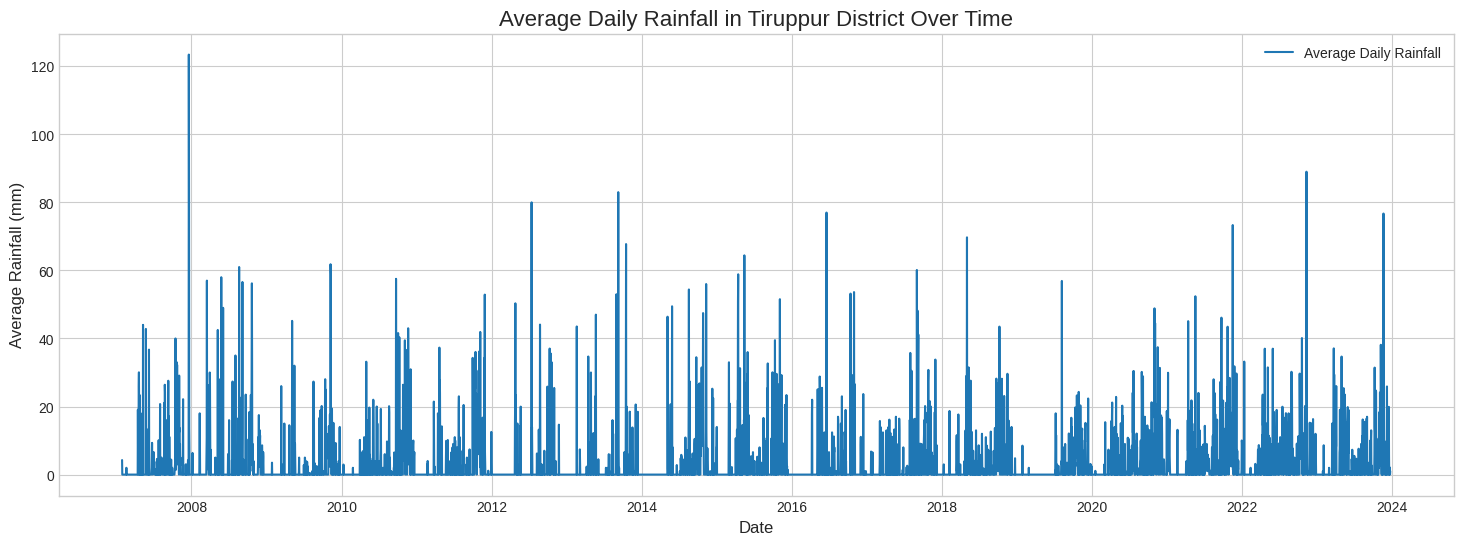

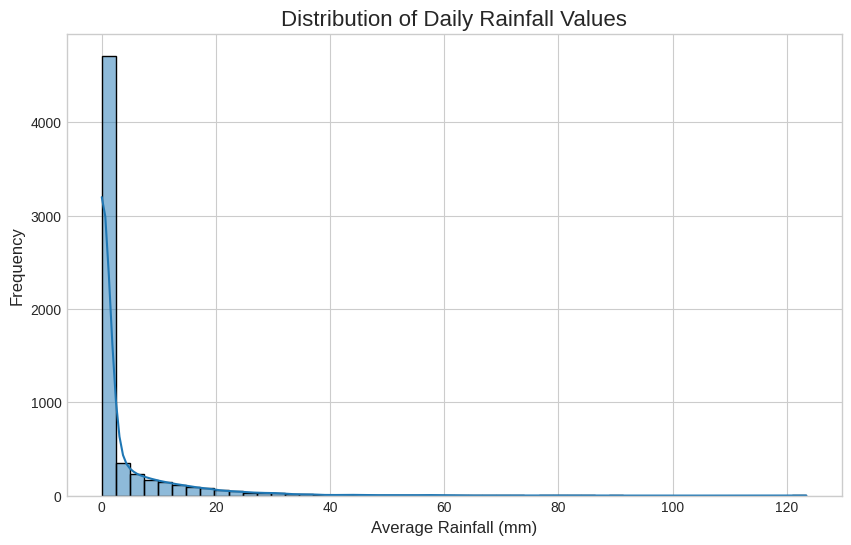

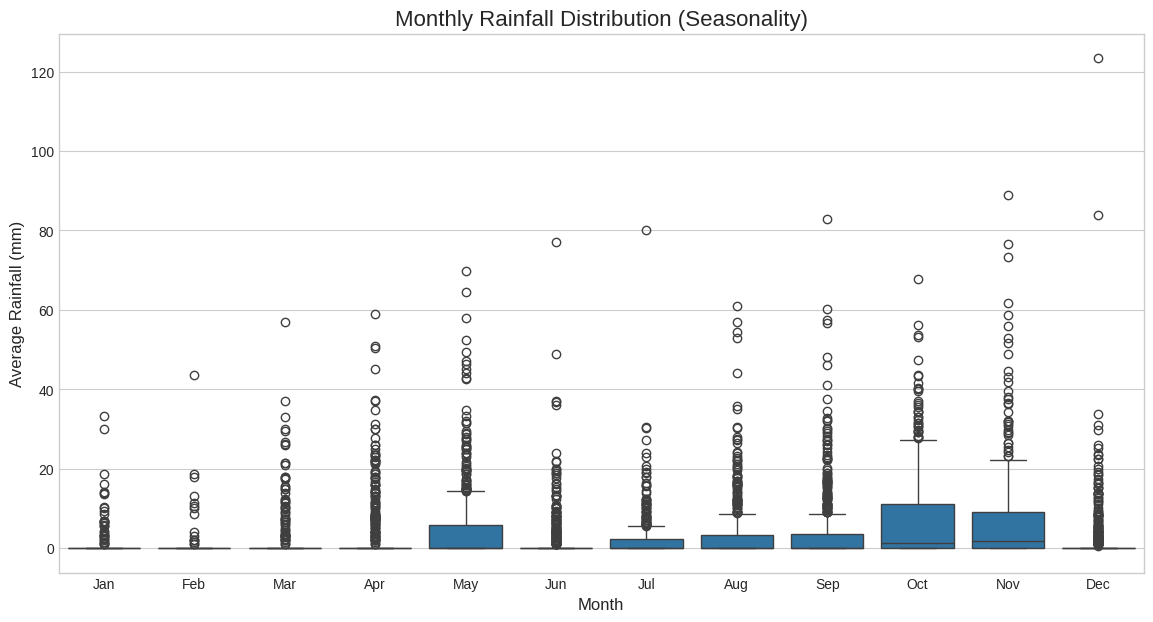

In [ ]:
# --- EDA Visualizations ---

plt.style.use('seaborn-v0_8-whitegrid')

# 1. Time Series Plot of Daily Rainfall
plt.figure(figsize=(18, 6))
plt.plot(daily_rainfall.index, daily_rainfall['avg_rainfall_mm'], label='Average Daily Rainfall')
plt.title('Average Daily Rainfall in Tiruppur District Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)
plt.legend()
plt.show()

# 2. Distribution of Rainfall
plt.figure(figsize=(10, 6))
sns.histplot(daily_rainfall['avg_rainfall_mm'], bins=50, kde=True)
plt.title('Distribution of Daily Rainfall Values', fontsize=16)
plt.xlabel('Average Rainfall (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()
# Note: The distribution is heavily skewed, with a vast majority of days having 0 or very low rainfall.

# 3. Box Plot for Monthly Seasonality
plt.figure(figsize=(14, 7))
daily_rainfall['month'] = daily_rainfall.index.month
sns.boxplot(x='month', y='avg_rainfall_mm', data=daily_rainfall)
plt.title('Monthly Rainfall Distribution (Seasonality)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()
# Note: This clearly shows the monsoon seasons, with higher rainfall typically from September to November.
daily_rainfall.drop('month', axis=1, inplace=True)

In [ ]:
# Get the rainfall data as a NumPy array
rainfall_data = daily_rainfall['avg_rainfall_mm'].values.reshape(-1, 1)

# Scale the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(rainfall_data)

# Split the data into training and testing sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f"Training data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")

Training data shape: (4940, 1)
Testing data shape: (1236, 1)


In [ ]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        # The input sequence is the data from i to i + time_steps
        X.append(data[i:(i + time_steps), 0])
        # The output is the data at i + time_steps
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 60 # Using 60 days of historical data to predict the next day

X_train, y_train = create_sequences(train_data, TIME_STEPS)
X_test, y_test = create_sequences(test_data, TIME_STEPS)

# Reshape input to be [samples, time_steps, features] which is required for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4880, 60, 1)
y_train shape: (4880,)
X_test shape: (1176, 60, 1)
y_test shape: (1176,)


In [ ]:
def build_model(hp):
    model = Sequential()

    # Tune the number of units in the first LSTM layer
    hp_units_1 = hp.Int('units_1', min_value=32, max_value=128, step=32)
    model.add(LSTM(units=hp_units_1, return_sequences=True, input_shape=(X_train.shape[1], 1)))

    # Tune the dropout rate
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_1))

    # Tune the number of units in the second LSTM layer
    hp_units_2 = hp.Int('units_2', min_value=32, max_value=128, step=32)
    model.add(LSTM(units=hp_units_2, return_sequences=False))

    # Tune the dropout rate
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_2))

    model.add(Dense(units=25))
    model.add(Dense(units=1))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mean_squared_error')

    return model

# Initialize the tuner (Hyperband is an efficient algorithm)
tuner = kt.Hyperband(build_model,
                     objective='val_loss',
                     max_epochs=50,
                     factor=3,
                     directory='keras_tuner_dir',
                     project_name='rainfall_forecasting')

# Create a callback to stop training early if validation loss is not improving
stop_early = EarlyStopping(monitor='val_loss', patience=10)

# Run the hyperparameter search
print("\n--- Starting Hyperparameter Search ---")
tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
--- Hyperparameter Search Complete ---
The optimal number of units in the first LSTM layer is {best_hps.get('units_1')}.
The optimal dropout rate for the first layer is {best_hps.get('dropout_1')}.
The optimal number of units in the second LSTM layer is {best_hps.get('units_2')}.
The optimal dropout rate for the second layer is {best_hps.get('dropout_2')}.
The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
""")

Trial 90 Complete [00h 00m 33s]
val_loss: 0.002097735647112131

Best val_loss So Far: 0.002059731399640441
Total elapsed time: 00h 35m 11s

--- Hyperparameter Search Complete ---
The optimal number of units in the first LSTM layer is 96.
The optimal dropout rate for the first layer is 0.4.
The optimal number of units in the second LSTM layer is 64.
The optimal dropout rate for the second layer is 0.1.
The optimal learning rate for the optimizer is 0.01.




--- Training the Final Model ---
Epoch 1/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0114

122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0114 - val_loss: 0.0023
Epoch 2/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 3/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0044 - val_loss: 0.0027
Epoch 4/100
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0048

122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0048 - val_loss: 0.0022
Epoch 5/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0047 - val_loss: 0.0023
Epoch 6/100
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041

122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0041 - val_loss: 0.0022
Epoch 7/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0039 - val_loss: 0.0023
Epoch 8/100
118/122 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0047

122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0046 - val_loss: 0.0021
Epoch 9/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0043 - val_loss: 0.0023
Epoch 10/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0042 - val_loss: 0.0022
Epoch 11/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0040 - val_loss: 0.0022
Epoch 12/100
118/122 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049

122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0049 - val_loss: 0.0021
Epoch 13/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0042 - val_loss: 0.0022
Epoch 14/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0043 - val_loss: 0.0023
Epoch 15/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0041 - val_loss: 0.0022
Epoch 16/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0043 - val_loss: 0.0024
Epoch 17/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0040 - val_loss: 0.0023
Epoch 18/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0045 - val_loss: 0.0021
Epoch 19/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0037 - val_loss: 0.0022
Epoch 20/100
120/122 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043

122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0043 - val_loss: 0.0021
Epoch 21/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0039 - val_loss: 0.0022
Epoch 22/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0043 - val_loss: 0.0023
Epoch 23/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0042 - val_loss: 0.0022
Epoch 24/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0041 - val_loss: 0.0021
Epoch 25/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0045 - val_loss: 0.0029
Epoch 26/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0039 - val_loss: 0.0027
Epoch 27/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0041 - val_loss: 0.0021
Epoch 28/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0041 - val_loss: 0.0024
Epoch 29/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0038 - val_loss: 0.0021
Epoch 30/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0038 - val_loss: 0.0021
Epoch 31/100
122/122 ━━━━━━━━━━━━━

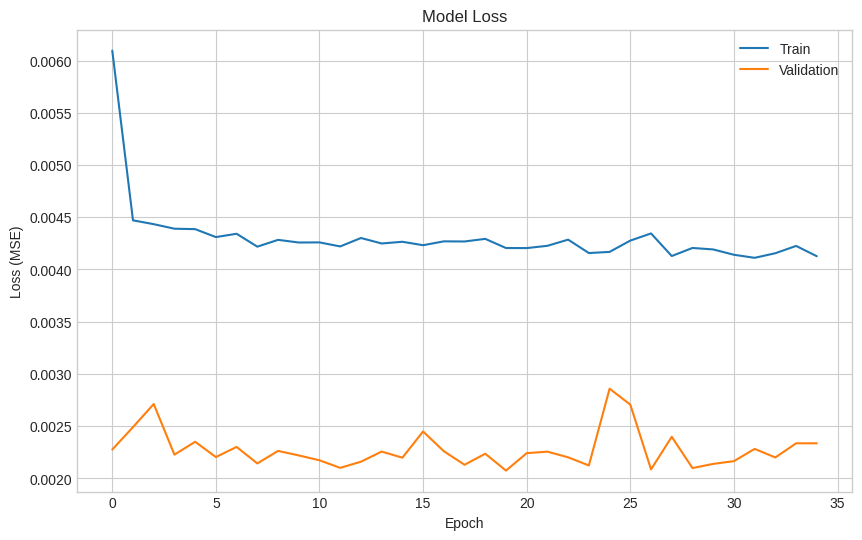

In [ ]:
# Build the model with the best hyperparameters
model = tuner.hypermodel.build(best_hps)

# Define callbacks
# ModelCheckpoint saves the best model found during training
model_checkpoint = ModelCheckpoint('best_rainfall_model.h5', save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True) # A bit more patience for final training

# Train the model
print("\n--- Training the Final Model ---")
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2, # Use part of training data for validation
                    callbacks=[early_stopping, model_checkpoint])

print("\n--- Model Training Complete ---")
print("Best model saved as 'best_rainfall_model.h5'")

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

--- Model Evaluation on Test Data ---
Root Mean Squared Error (RMSE): 8.0540
Mean Absolute Error (MAE): 4.4918


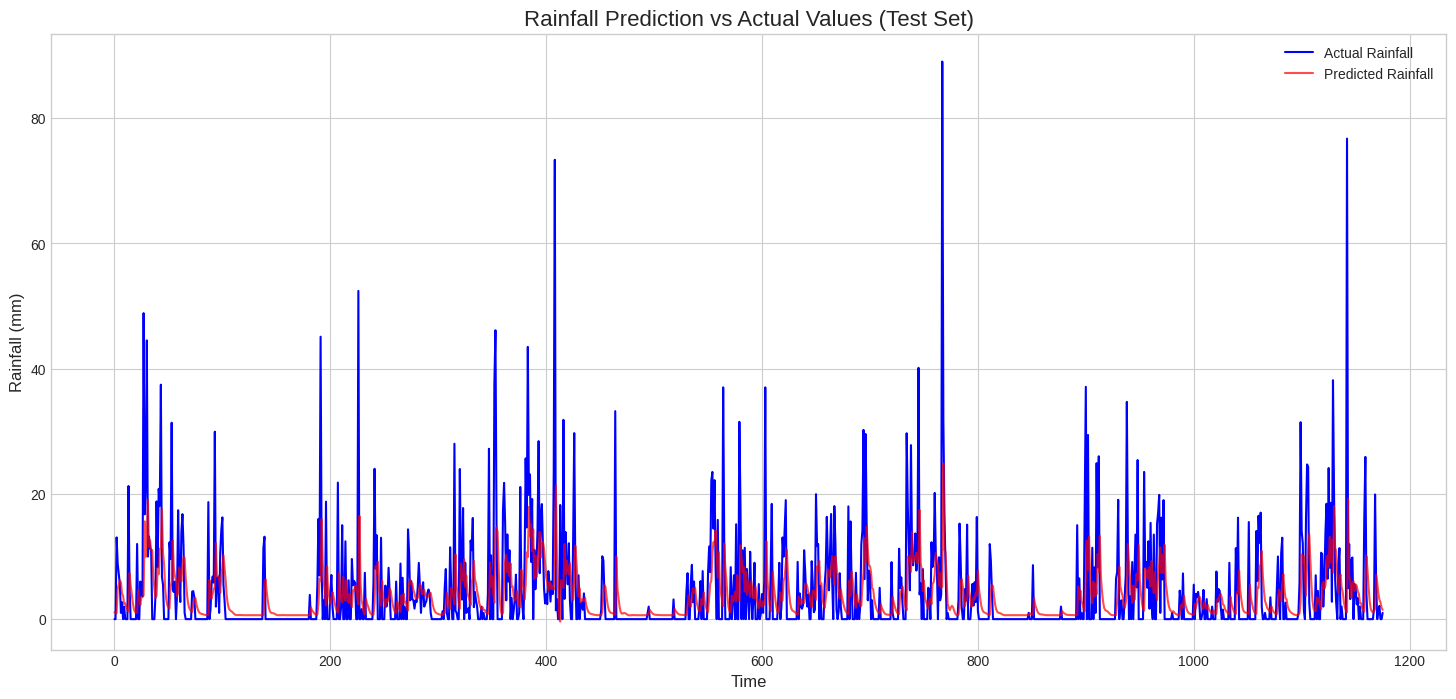

In [ ]:
# Load the best saved model
saved_model = load_model('best_rainfall_model.h5')

# Make predictions on the test set
predictions_scaled = saved_model.predict(X_test)

# Inverse transform the predictions and actual values to the original scale
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)

print("\n--- Model Evaluation on Test Data ---")
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')

# Visualize the predictions vs actual values
plt.figure(figsize=(18, 8))
plt.plot(y_test_actual, color='blue', label='Actual Rainfall')
plt.plot(predictions, color='red', alpha=0.7, label='Predicted Rainfall')
plt.title('Rainfall Prediction vs Actual Values (Test Set)', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.legend()
plt.show()

In [ ]:
# --- Forecasting the Next Day ---

# Load the saved model again (to simulate a real-world use case)
forecasting_model = load_model('best_rainfall_model.h5')

# Get the last `TIME_STEPS` days from the original scaled dataset to make a prediction
last_60_days = scaled_data[-TIME_STEPS:]

# Reshape it to the format expected by the model [1, time_steps, features]
input_for_pred = last_60_days.reshape(1, TIME_STEPS, 1)

# Predict the next day's rainfall (output will be scaled)
predicted_scaled_value = forecasting_model.predict(input_for_pred)

# Inverse transform the prediction to get the actual rainfall value
predicted_rainfall = scaler.inverse_transform(predicted_scaled_value)

# Get the last date in the dataset to know what day we are predicting for
last_date = daily_rainfall.index[-1]
next_day = last_date + pd.Timedelta(days=1)


print("\n--- Future Forecast ---")
print(f"The forecasted average rainfall for {next_day.date()} is: {predicted_rainfall[0][0]:.2f} mm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step

--- Future Forecast ---
The forecasted average rainfall for 2023-12-26 is: 1.61 mm
